<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 8.2 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 27.7 MB/s eta 0:00:00:00:01


In [2]:
!pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 142.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 140.6 MB/s eta 0:00:00


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-02-24 19:37:13--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  43.6MB/s    in 3.5s    

2026-02-24 19:37:17 (44.0 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [5]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [7]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



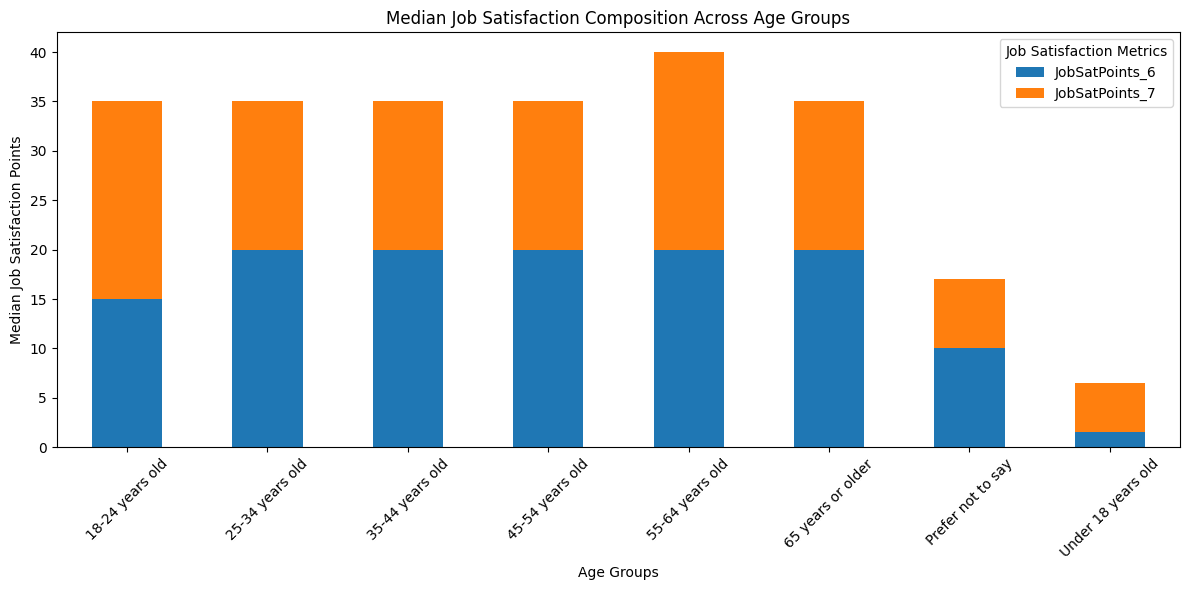

In [8]:
##Write your code here
df_clean = df[['Age', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()

median_data = df_clean.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()

# Stacked Bar Chart
median_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Median Job Satisfaction Composition Across Age Groups")
plt.xlabel("Age Groups")
plt.ylabel("Median Job Satisfaction Points")
plt.xticks(rotation=45)
plt.legend(title="Job Satisfaction Metrics")
plt.tight_layout()
plt.show()

Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


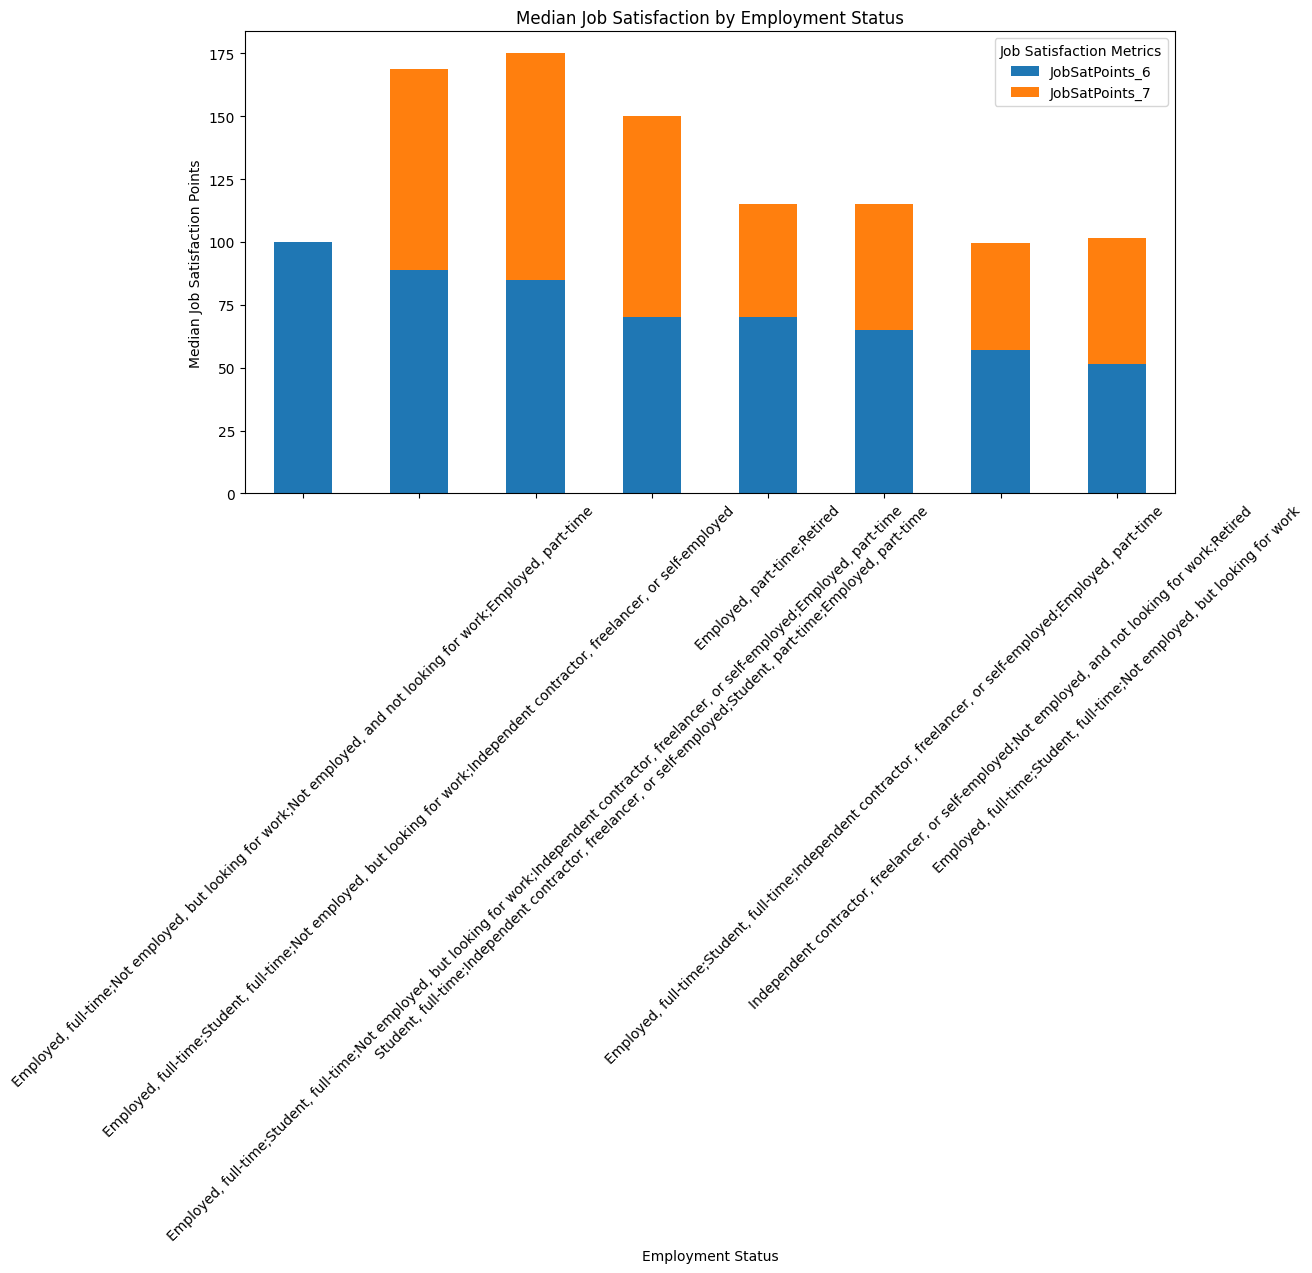

In [11]:
##Write your code here
df_clean = df[['Employment', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()
median_data = df_clean.groupby('Employment')[['JobSatPoints_6', 'JobSatPoints_7']].median()
median_data = median_data.sort_values(
    by=['JobSatPoints_6','JobSatPoints_7'], ascending=False).head(8)
median_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Median Job Satisfaction by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Median Job Satisfaction Points")
plt.xticks(rotation=45)
plt.legend(title="Job Satisfaction Metrics")

plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


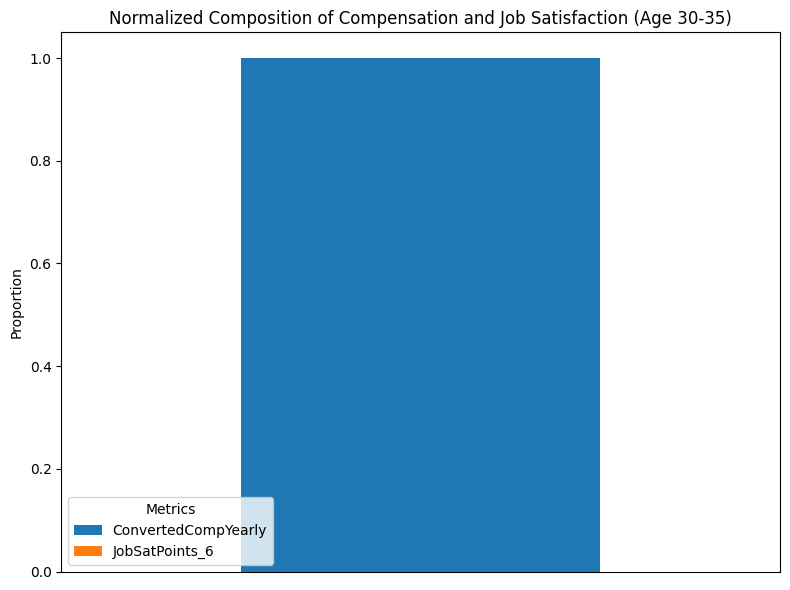

In [13]:
##Write your code here
def age_to_numeric(age_str):
    if pd.isnull(age_str):
        return None
    if age_str == 'Under 18 years old':
        return 16
    elif age_str == '18-24 years old':
        return 21
    elif age_str == '25-34 years old':
        return 30
    elif age_str == '35-44 years old':
        return 40
    elif age_str == '45-54 years old':
        return 50
    elif age_str == '55-64 years old':
        return 60
    elif age_str == '65 years or older':
        return 70
    else:
        return None

df['Age_numeric'] = df['Age'].apply(age_to_numeric)
age_30_35 = df[(df['Age_numeric'] >= 30) & (df['Age_numeric'] <= 35)]

# 4) حذف القيم الناقصة
age_30_35_clean = age_30_35[['ConvertedCompYearly', 'JobSatPoints_6']].dropna()

# 5) حساب Median
median_values = age_30_35_clean.median()

# 6) تحويلها DataFrame للرسم
median_df = pd.DataFrame(median_values).T

# 7) رسم Stacked Bar Chart
median_df.plot(
    kind='bar',
    stacked=True,
    figsize=(8,6)
)

plt.title("Median Compensation and Job Satisfaction (Age 30-35)")
plt.ylabel("Median Values")
plt.xticks([])
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


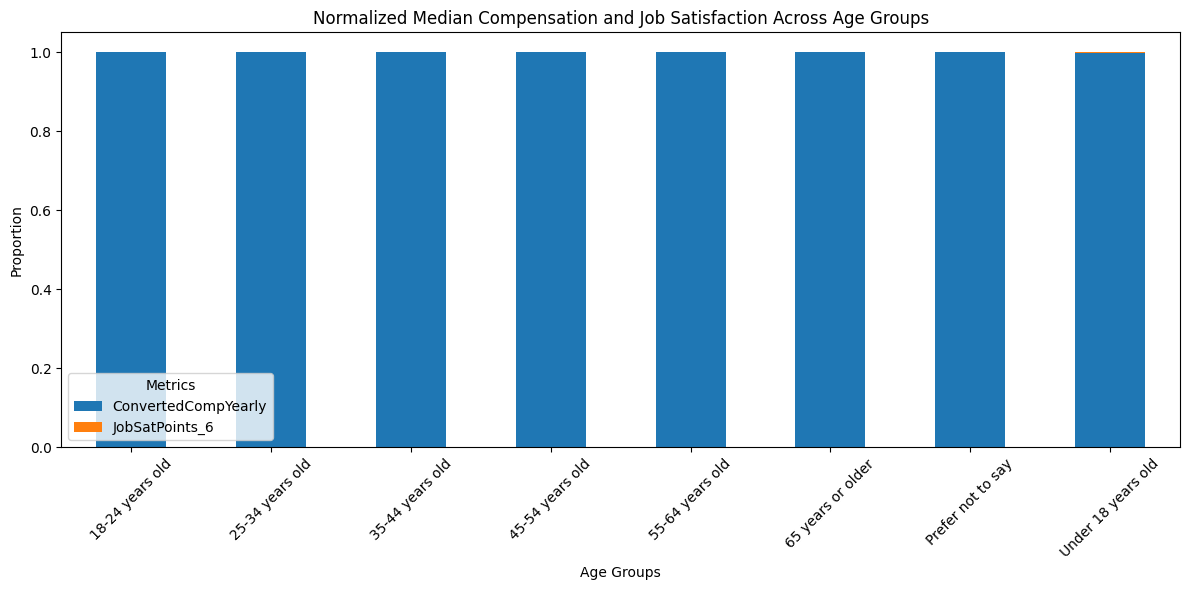

In [15]:
##Write your code here

df_clean = df[['Age', 'ConvertedCompYearly', 'JobSatPoints_6']].dropna()

# 4) Median
median_data = df_clean.groupby('Age')[['ConvertedCompYearly', 'JobSatPoints_6']].median()

# Normalization
median_normalized = median_data.div(median_data.sum(axis=1), axis=0)

#Stacked Chart
median_normalized.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Normalized Median Compensation and Job Satisfaction Across Age Groups")
plt.xlabel("Age Groups")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


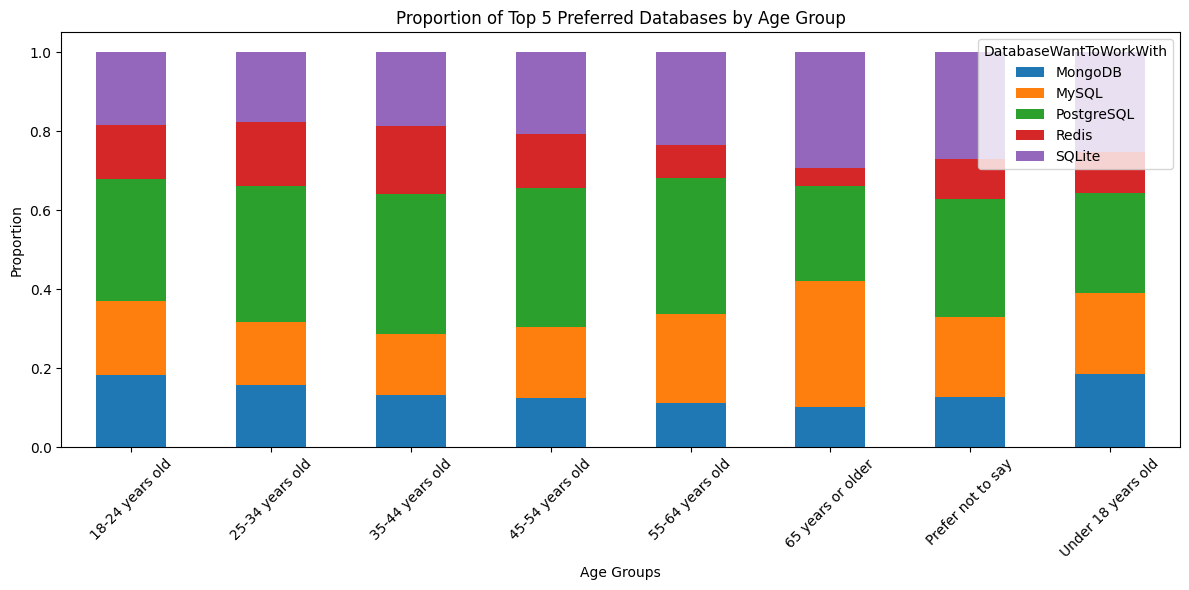

In [19]:
##Write your code here
# حذف القيم الفارغة
df_db = df[['Age', 'DatabaseWantToWorkWith']].dropna()
# فصل القيم
df_db['DatabaseWantToWorkWith'] = df_db['DatabaseWantToWorkWith'].str.split(';')

# explode + reset index
df_db = df_db.explode('DatabaseWantToWorkWith').reset_index(drop=True)
df_db['DatabaseWantToWorkWith'] = df_db['DatabaseWantToWorkWith'].str.strip()

# Top 5
top5_databases = df_db['DatabaseWantToWorkWith'].value_counts().head(5).index
df_top = df_db[df_db['DatabaseWantToWorkWith'].isin(top5_databases)]

# Crosstab
crosstab = pd.crosstab(
    df_top['Age'],
    df_top['DatabaseWantToWorkWith']
)

crosstab_normalized = crosstab.div(crosstab.sum(axis=1), axis=0)

crosstab_normalized.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Proportion of Top 5 Preferred Databases by Age Group")
plt.xlabel("Age Groups")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


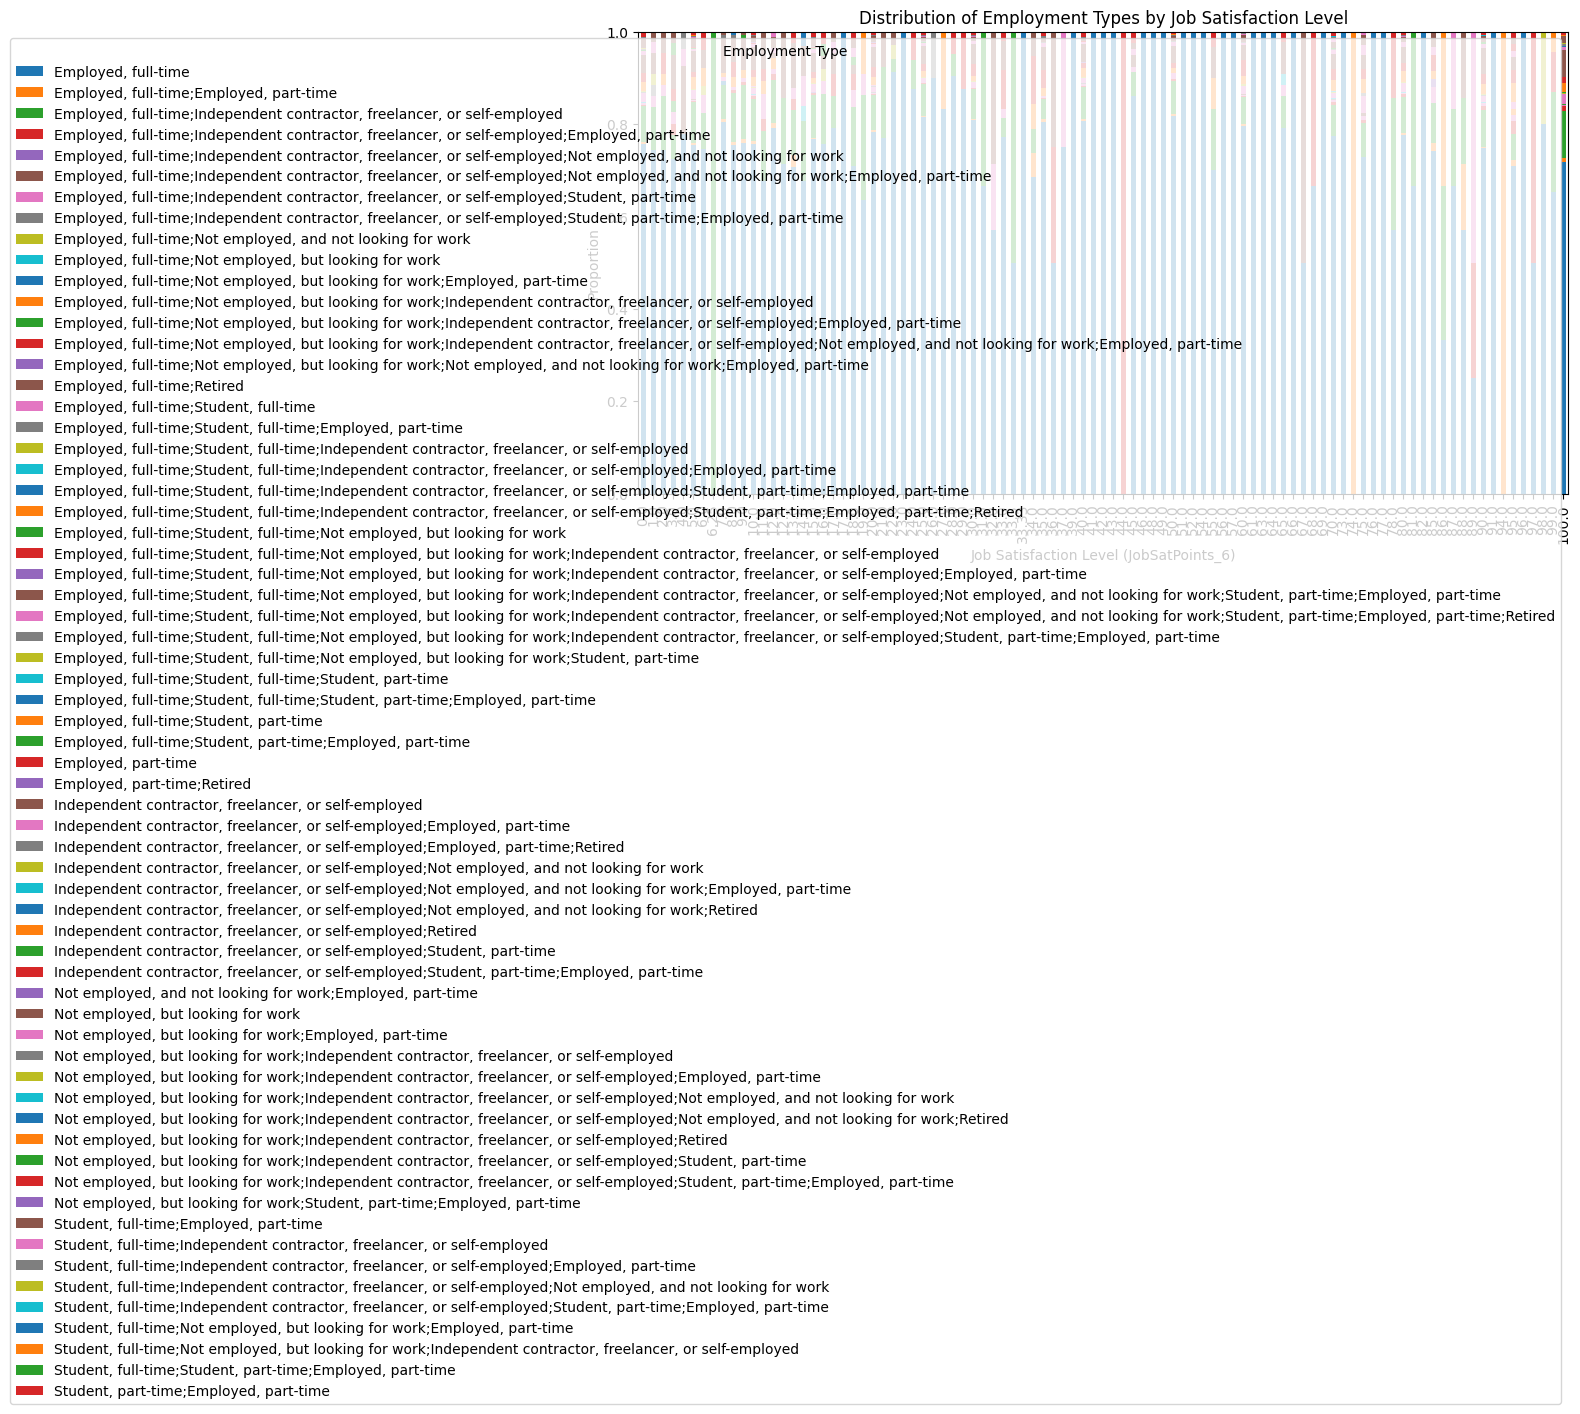

In [21]:
##Write your code here

# 2) حذف القيم الناقصة
df_clean = df[['Employment', 'JobSatPoints_6']].dropna()
crosstab = pd.crosstab(
    df_clean['JobSatPoints_6'],
    df_clean['Employment']
)

# 4) تحويل إلى نسب داخل كل مستوى رضا
crosstab_normalized = crosstab.div(crosstab.sum(axis=1), axis=0)

# 5) Stacked Chart
crosstab_normalized.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Distribution of Employment Types by Job Satisfaction Level")
plt.xlabel("Job Satisfaction Level (JobSatPoints_6)")
plt.ylabel("Proportion")
plt.legend(title="Employment Type")
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


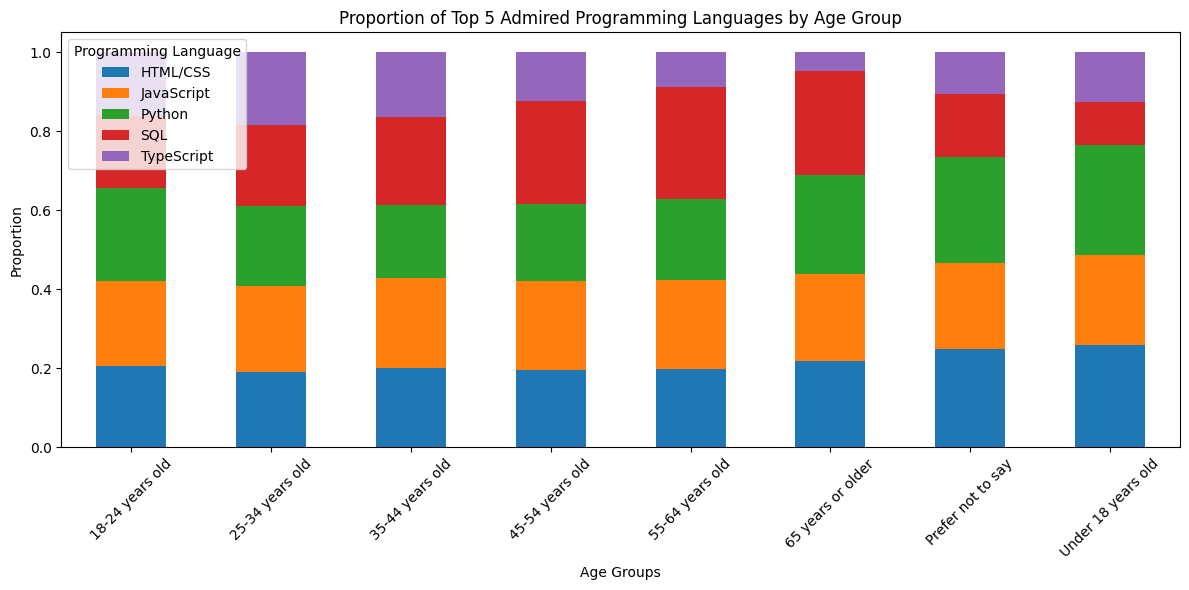

In [22]:
##Write your code here
df_lang = df[['Age', 'LanguageAdmired']].dropna()

df_lang['LanguageAdmired'] = df_lang['LanguageAdmired'].str.split(';')

df_lang = df_lang.explode('LanguageAdmired').reset_index(drop=True)

df_lang['LanguageAdmired'] = df_lang['LanguageAdmired'].str.strip()

top5_langs = df_lang['LanguageAdmired'].value_counts().head(5).index
df_top = df_lang[df_lang['LanguageAdmired'].isin(top5_langs)]

crosstab = pd.crosstab(
    df_top['Age'],
    df_top['LanguageAdmired']
)

crosstab_normalized = crosstab.div(crosstab.sum(axis=1), axis=0)

crosstab_normalized.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Proportion of Top 5 Admired Programming Languages by Age Group")
plt.xlabel("Age Groups")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Programming Language")
plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


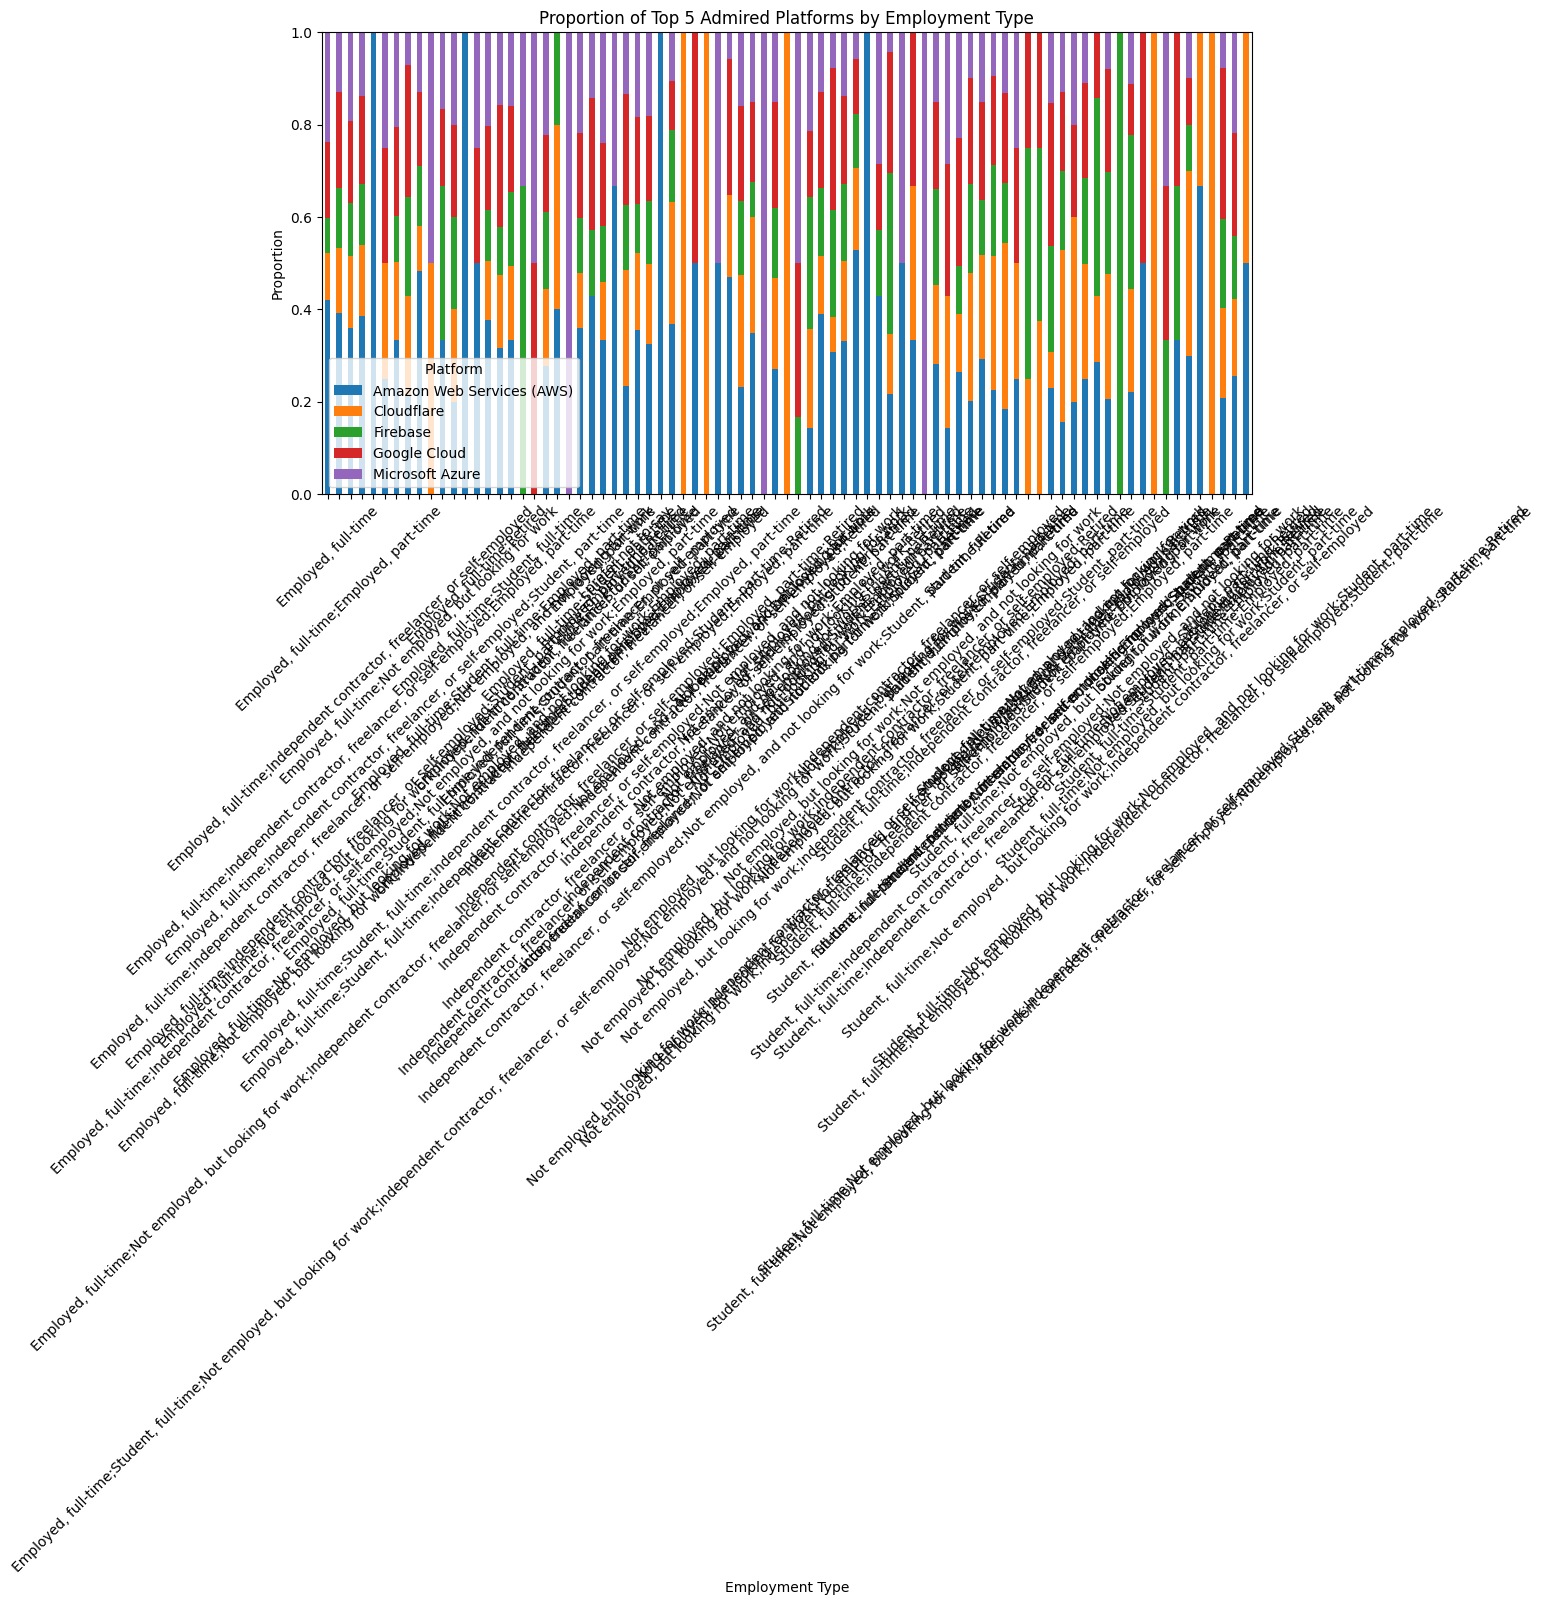

In [24]:
##Write your code here
df_platform = df[['Employment', 'PlatformAdmired']].dropna()

df_platform['PlatformAdmired'] = df_platform['PlatformAdmired'].str.split(';')

df_platform = df_platform.explode('PlatformAdmired').reset_index(drop=True)

df_platform['PlatformAdmired'] = df_platform['PlatformAdmired'].str.strip()

top5_platforms = df_platform['PlatformAdmired'].value_counts().head(5).index
df_top = df_platform[df_platform['PlatformAdmired'].isin(top5_platforms)]

crosstab = pd.crosstab(
    df_top['Employment'],
    df_top['PlatformAdmired']
)

crosstab_normalized = crosstab.div(crosstab.sum(axis=1), axis=0)
crosstab_normalized.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Proportion of Top 5 Admired Platforms by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Platform")
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
